In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Read-only connection for EDA
con = duckdb.connect("developer_project.duckdb", read_only=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

print("Tables in database:")
print(con.execute("SHOW TABLES").fetchdf())

Tables in database:
                                      name
0                          activity_capped
1                           activity_clean
2                           activity_final
3                             activity_raw
4                          activity_sample
5                    activity_score_bounds
6             activity_score_mapping_clean
7               activity_score_mapping_raw
8                          activity_scored
9                           activity_stage
10                   activity_standardized
11                  activity_user_features
12                           contact_clean
13  contact_clean_backup_before_supplement
14                           contact_final
15                             contact_raw
16                          contact_sample
17                           contact_stage
18                contact_supplement_clean
19                  contact_supplement_raw
20                  developer_feature_base
21                      sdk_downlo

In [2]:
print("\nFinal row count and distinct users:")
print(con.execute("""
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT developer_id) AS distinct_users
FROM developer_feature_base
""").fetchdf())

print("\nDuplicate developer_id check:")
print(con.execute("""
SELECT developer_id, COUNT(*) AS cnt
FROM developer_feature_base
GROUP BY developer_id
HAVING COUNT(*) > 1
LIMIT 20
""").fetchdf())

print("\nMissing developer_id check:")
print(con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN developer_id IS NULL OR TRIM(developer_id) = '' THEN 1 ELSE 0 END) AS missing_developer_id
FROM developer_feature_base
""").fetchdf())

print("\nJoin coverage:")
print(con.execute("""
SELECT
    COUNT(DISTINCT c.developer_id) AS total_contact_users,
    COUNT(DISTINCT a.developer_id) AS matched_activity_users,
    COUNT(DISTINCT c.developer_id) - COUNT(DISTINCT a.developer_id) AS users_without_activity
FROM contact_final c
LEFT JOIN activity_user_features a
    ON c.developer_id = a.developer_id
""").fetchdf())

print("\nFeature null checks:")
print(con.execute("""
SELECT
    SUM(CASE WHEN total_activities_all_time IS NULL THEN 1 ELSE 0 END) AS null_total_activities,
    SUM(CASE WHEN total_activity_score_all_time IS NULL THEN 1 ELSE 0 END) AS null_total_score,
    SUM(CASE WHEN days_since_last_activity IS NULL THEN 1 ELSE 0 END) AS null_days_since_last_activity
FROM developer_feature_base
""").fetchdf())

print("\nFeature distribution summary:")
print(con.execute("""
SELECT
    MIN(total_activities_all_time) AS min_total_activities,
    MAX(total_activities_all_time) AS max_total_activities,
    AVG(total_activities_all_time) AS avg_total_activities,
    MIN(total_activity_score_all_time) AS min_total_score,
    MAX(total_activity_score_all_time) AS max_total_score,
    AVG(total_activity_score_all_time) AS avg_total_score
FROM developer_feature_base
""").fetchdf())

print("\nRecent activity window checks:")
print(con.execute("""
SELECT
    SUM(CASE WHEN activity_cnt_30d > activity_cnt_90d THEN 1 ELSE 0 END) AS bad_30_gt_90,
    SUM(CASE WHEN activity_cnt_90d > activity_cnt_180d THEN 1 ELSE 0 END) AS bad_90_gt_180,
    SUM(CASE WHEN activity_cnt_180d > activity_cnt_360d THEN 1 ELSE 0 END) AS bad_180_gt_360
FROM developer_feature_base
""").fetchdf())

print("\nScore window checks:")
print(con.execute("""
SELECT
    SUM(CASE WHEN activity_score_30d > activity_score_90d THEN 1 ELSE 0 END) AS bad_score_30_gt_90,
    SUM(CASE WHEN activity_score_90d > activity_score_180d THEN 1 ELSE 0 END) AS bad_score_90_gt_180,
    SUM(CASE WHEN activity_score_180d > activity_score_360d THEN 1 ELSE 0 END) AS bad_score_180_gt_360
FROM developer_feature_base
""").fetchdf())

print("\nPreview final joined dataset:")
print(con.execute("""
SELECT *
FROM developer_feature_base
LIMIT 20
""").fetchdf())




Final row count and distinct users:
   row_count  distinct_users
0    9381490         9381490

Duplicate developer_id check:
Empty DataFrame
Columns: [developer_id, cnt]
Index: []

Missing developer_id check:
   total_rows  missing_developer_id
0     9381490                   0.0

Join coverage:
   total_contact_users  matched_activity_users  users_without_activity
0              9381490                 7654410                 1727080

Feature null checks:
   null_total_activities  null_total_score  null_days_since_last_activity
0                    0.0               0.0                            0.0

Feature distribution summary:
   min_total_activities  max_total_activities  avg_total_activities  \
0                     0               2027375              7.281723   

   min_total_score  max_total_score  avg_total_score  
0              0.0       10015777.0        24.284601  

Recent activity window checks:
   bad_30_gt_90  bad_90_gt_180  bad_180_gt_360
0           0.0            

In [3]:
print("\nQuantiles for total activities:")
print(con.execute("""
SELECT
    QUANTILE_CONT(total_activities_all_time, 0.50) AS p50,
    QUANTILE_CONT(total_activities_all_time, 0.90) AS p90,
    QUANTILE_CONT(total_activities_all_time, 0.99) AS p99,
    QUANTILE_CONT(total_activities_all_time, 0.999) AS p999,
    MAX(total_activities_all_time) AS max_val
FROM developer_feature_base
""").fetchdf())

print("\nQuantiles for total activity score:")
print(con.execute("""
SELECT
    QUANTILE_CONT(total_activity_score_all_time, 0.50) AS p50,
    QUANTILE_CONT(total_activity_score_all_time, 0.90) AS p90,
    QUANTILE_CONT(total_activity_score_all_time, 0.99) AS p99,
    QUANTILE_CONT(total_activity_score_all_time, 0.999) AS p999,
    MAX(total_activity_score_all_time) AS max_val
FROM developer_feature_base
""").fetchdf())

print("\nUsers without activity by source:")
print(con.execute("""
SELECT
    program_application_source,
    COUNT(*) AS users_without_activity
FROM developer_feature_base
WHERE total_activities_all_time = 0
GROUP BY 1
ORDER BY 2 DESC
LIMIT 20
""").fetchdf())

print("\nUsers without activity by country:")
print(con.execute("""
SELECT
    country,
    COUNT(*) AS users_without_activity
FROM developer_feature_base
WHERE total_activities_all_time = 0
GROUP BY 1
ORDER BY 2 DESC
LIMIT 20
""").fetchdf())

print("\nTop 20 most active users:")
print(con.execute("""
SELECT developer_id, total_activities_all_time, total_activity_score_all_time
FROM developer_feature_base
ORDER BY total_activities_all_time DESC, total_activity_score_all_time DESC
LIMIT 20
""").fetchdf())


Quantiles for total activities:
   p50  p90    p99   p999  max_val
0  2.0  7.0  114.0  568.0  2027375

Quantiles for total activity score:
   p50   p90    p99      p999     max_val
0  4.0  36.0  341.0  1540.511  10015777.0

Users without activity by source:
   program_application_source  users_without_activity
0                     unknown                 1264055
1                     devzone                  389421
2               gtc fall 2022                   47572
3             gtc spring 2022                   13584
4                 api_catalog                    9362
5                         gtc                    2489
6                         dli                     486
7                        brev                      74
8                         nod                      21
9                         hwg                      14
10                        ngc                       2

Users without activity by country:
               country  users_without_activity
0         

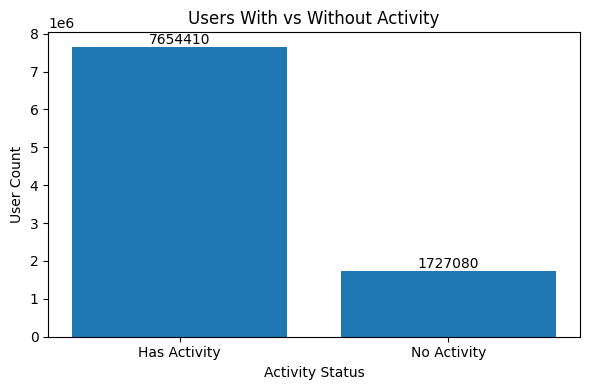

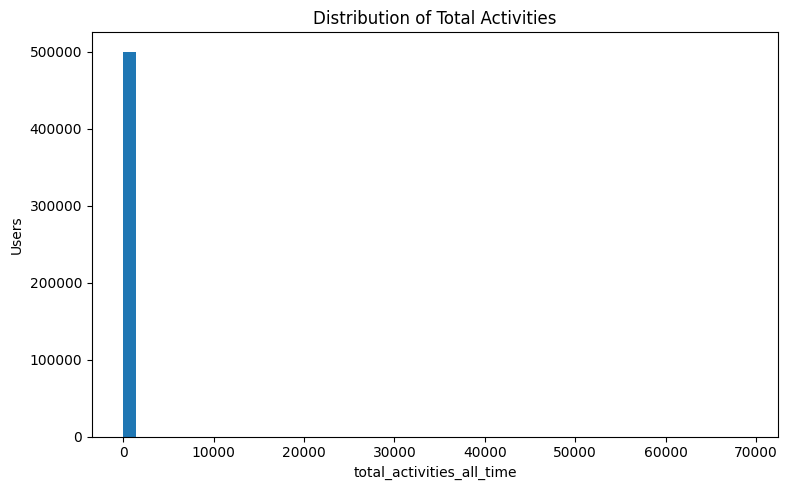

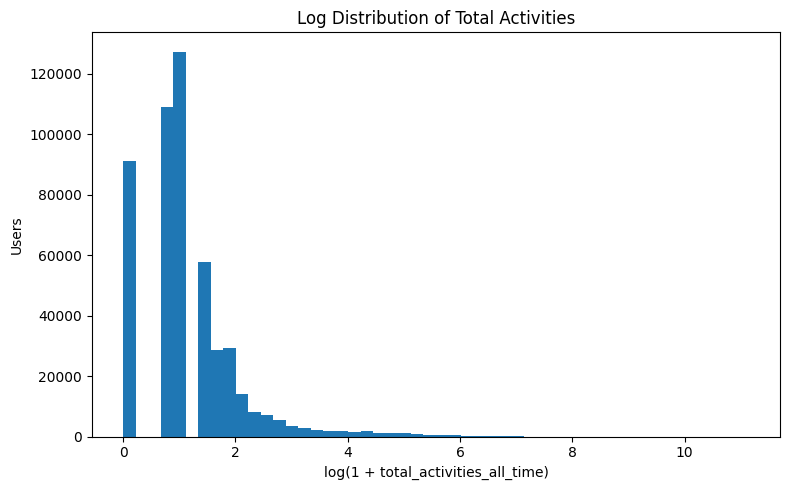

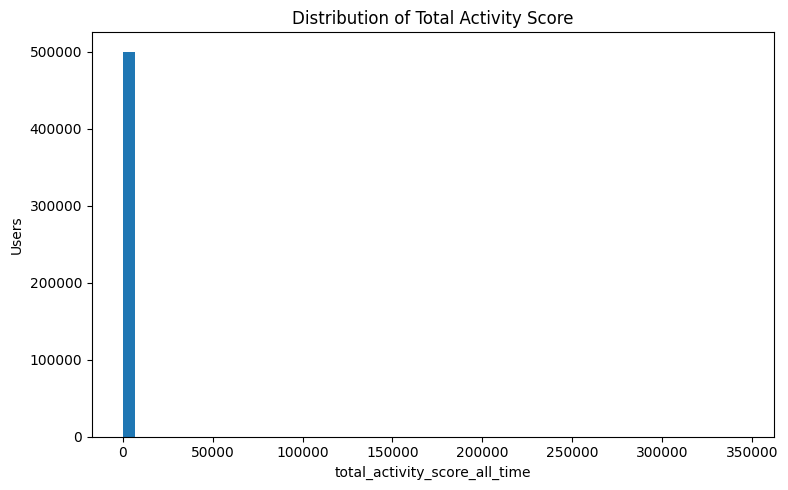

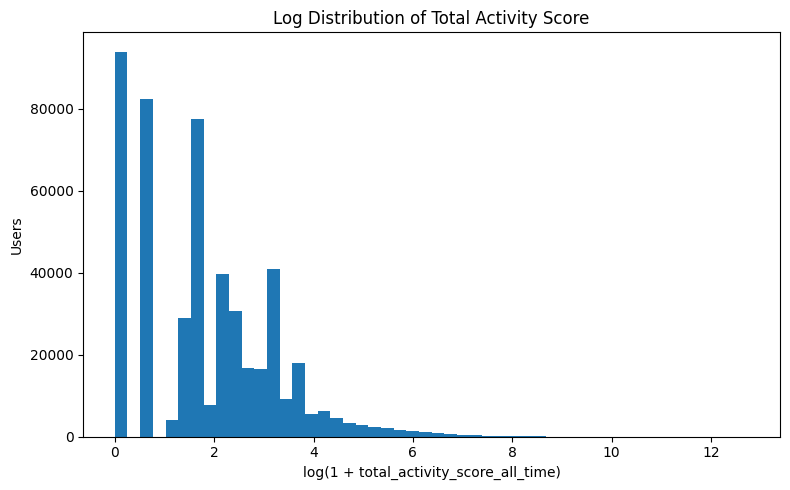

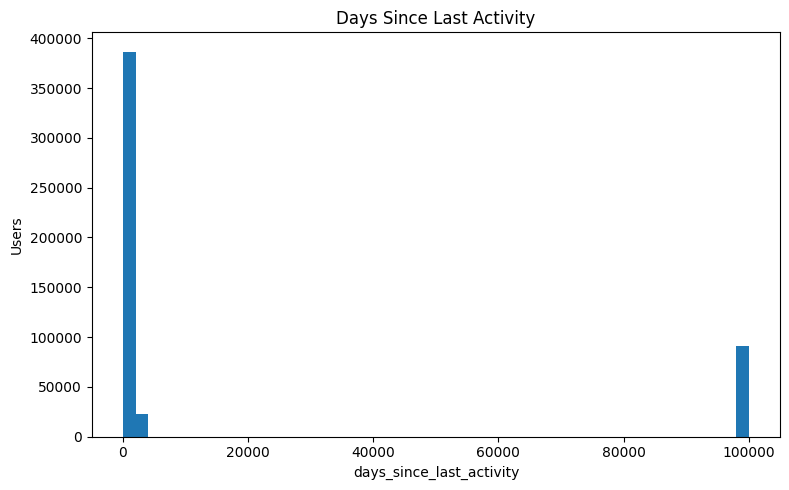

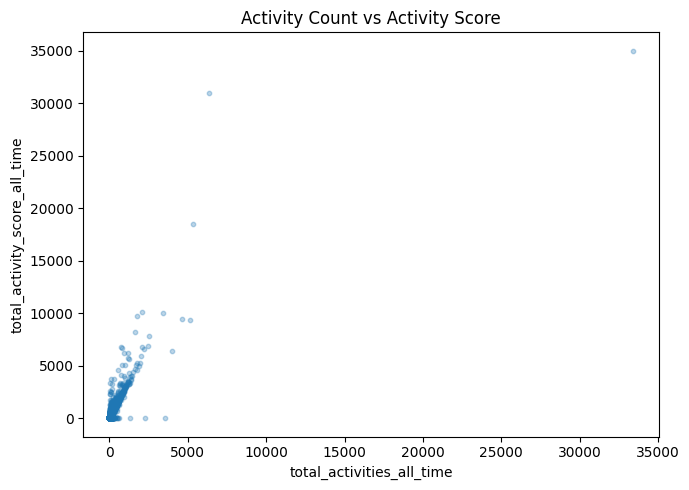

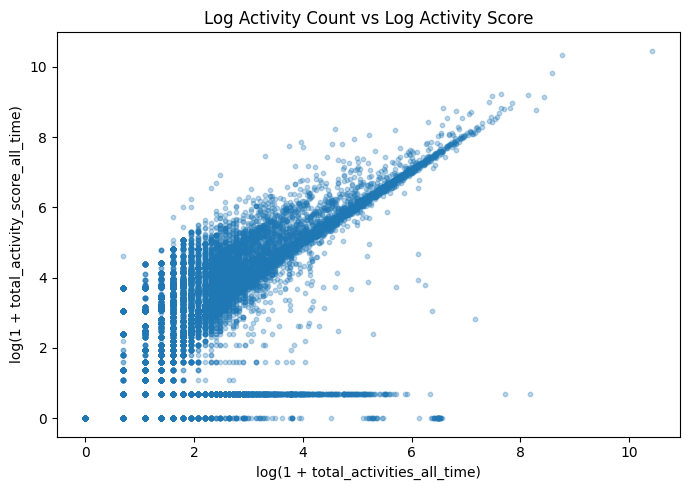

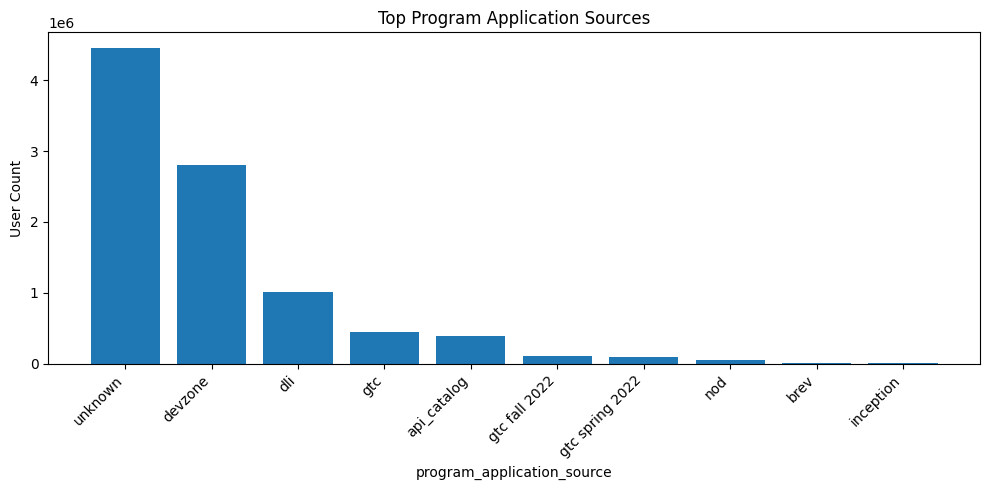

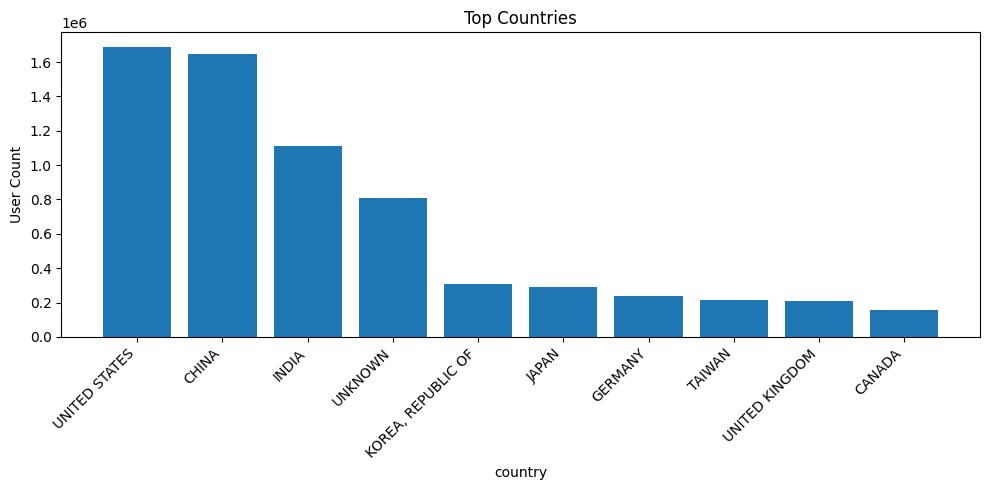

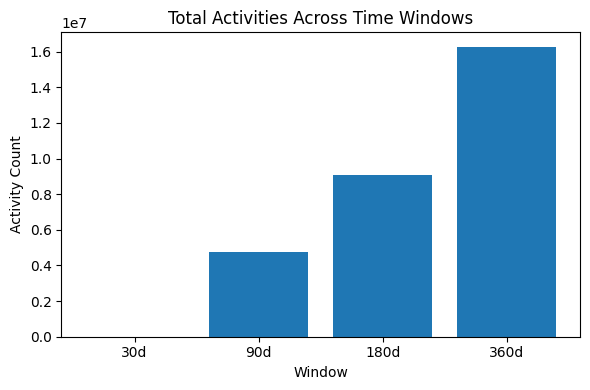

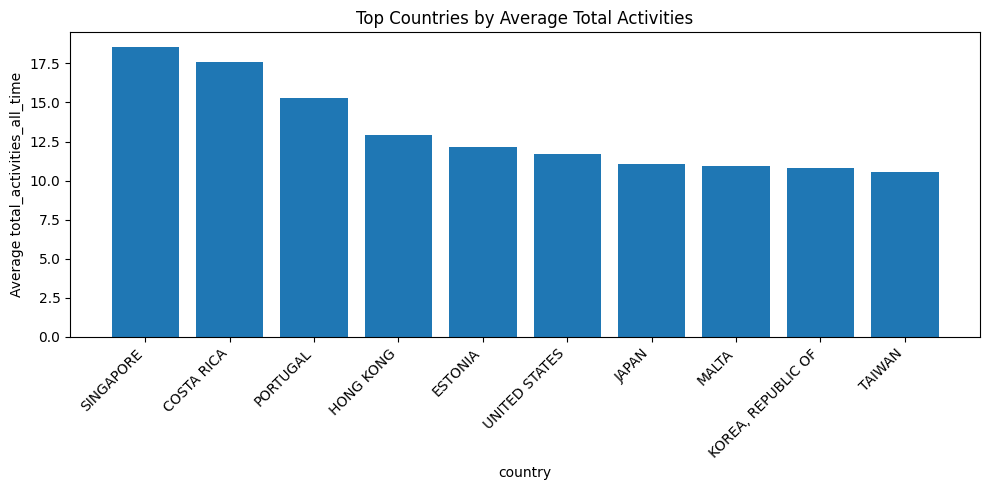

In [4]:

# 3.1 Users with vs without activity
df = con.execute("""
SELECT
    CASE
        WHEN total_activities_all_time = 0 THEN 'No Activity'
        ELSE 'Has Activity'
    END AS activity_status,
    COUNT(*) AS user_count
FROM developer_feature_base
GROUP BY 1
ORDER BY 2 DESC
""").fetchdf()

plt.figure(figsize=(6, 4))

bars = plt.bar(df["activity_status"], df["user_count"])

plt.title("Users With vs Without Activity")
plt.xlabel("Activity Status")
plt.ylabel("User Count")

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# 3.2 Distribution of total activities
df = con.execute("""
SELECT total_activities_all_time
FROM developer_feature_base
WHERE total_activities_all_time IS NOT NULL
LIMIT 500000
""").fetchdf()

plt.figure(figsize=(8, 5))
plt.hist(df["total_activities_all_time"], bins=50)
plt.title("Distribution of Total Activities")
plt.xlabel("total_activities_all_time")
plt.ylabel("Users")
plt.tight_layout()
plt.show()


# 3.3 Log distribution of total activities
df = con.execute("""
SELECT LN(1 + total_activities_all_time) AS log_total_activities
FROM developer_feature_base
WHERE total_activities_all_time IS NOT NULL
LIMIT 500000
""").fetchdf()

plt.figure(figsize=(8, 5))
plt.hist(df["log_total_activities"], bins=50)
plt.title("Log Distribution of Total Activities")
plt.xlabel("log(1 + total_activities_all_time)")
plt.ylabel("Users")
plt.tight_layout()
plt.show()


# 3.4 Distribution of total activity score
df = con.execute("""
SELECT total_activity_score_all_time
FROM developer_feature_base
WHERE total_activity_score_all_time IS NOT NULL
LIMIT 500000
""").fetchdf()

plt.figure(figsize=(8, 5))
plt.hist(df["total_activity_score_all_time"], bins=50)
plt.title("Distribution of Total Activity Score")
plt.xlabel("total_activity_score_all_time")
plt.ylabel("Users")
plt.tight_layout()
plt.show()


# 3.5 Log distribution of total activity score
df = con.execute("""
SELECT LN(1 + total_activity_score_all_time) AS log_total_score
FROM developer_feature_base
WHERE total_activity_score_all_time IS NOT NULL
LIMIT 500000
""").fetchdf()

plt.figure(figsize=(8, 5))
plt.hist(df["log_total_score"], bins=50)
plt.title("Log Distribution of Total Activity Score")
plt.xlabel("log(1 + total_activity_score_all_time)")
plt.ylabel("Users")
plt.tight_layout()
plt.show()


# 3.6 Days since last activity
df = con.execute("""
SELECT days_since_last_activity
FROM developer_feature_base
WHERE days_since_last_activity IS NOT NULL
LIMIT 500000
""").fetchdf()

plt.figure(figsize=(8, 5))
plt.hist(df["days_since_last_activity"], bins=50)
plt.title("Days Since Last Activity")
plt.xlabel("days_since_last_activity")
plt.ylabel("Users")
plt.tight_layout()
plt.show()


# 3.7 Activity count vs activity score
df = con.execute("""
SELECT
    total_activities_all_time,
    total_activity_score_all_time
FROM developer_feature_base
WHERE total_activities_all_time > 0
  AND total_activity_score_all_time > 0
LIMIT 100000
""").fetchdf()

plt.figure(figsize=(7, 5))
plt.scatter(
    df["total_activities_all_time"],
    df["total_activity_score_all_time"],
    alpha=0.3,
    s=10
)
plt.title("Activity Count vs Activity Score")
plt.xlabel("total_activities_all_time")
plt.ylabel("total_activity_score_all_time")
plt.tight_layout()
plt.show()


# 3.8 Log activity count vs log activity score
df = con.execute("""
SELECT
    LN(1 + total_activities_all_time) AS log_activities,
    LN(1 + total_activity_score_all_time) AS log_score
FROM developer_feature_base
WHERE total_activities_all_time >= 0
  AND total_activity_score_all_time >= 0
LIMIT 100000
""").fetchdf()

plt.figure(figsize=(7, 5))
plt.scatter(
    df["log_activities"],
    df["log_score"],
    alpha=0.3,
    s=10
)
plt.title("Log Activity Count vs Log Activity Score")
plt.xlabel("log(1 + total_activities_all_time)")
plt.ylabel("log(1 + total_activity_score_all_time)")
plt.tight_layout()
plt.show()


# 3.9 Top program application sources
df = con.execute("""
SELECT program_application_source, COUNT(*) AS user_count
FROM developer_feature_base
GROUP BY 1
ORDER BY user_count DESC
LIMIT 10
""").fetchdf()

plt.figure(figsize=(10, 5))
plt.bar(df["program_application_source"], df["user_count"])
plt.title("Top Program Application Sources")
plt.xlabel("program_application_source")
plt.ylabel("User Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# 3.10 Top countries
df = con.execute("""
SELECT country, COUNT(*) AS user_count
FROM developer_feature_base
GROUP BY 1
ORDER BY user_count DESC
LIMIT 10
""").fetchdf()

plt.figure(figsize=(10, 5))
plt.bar(df["country"], df["user_count"])
plt.title("Top Countries")
plt.xlabel("country")
plt.ylabel("User Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# 3.11 Activity totals across windows
df = con.execute("""
SELECT
    SUM(activity_cnt_30d) AS cnt_30d,
    SUM(activity_cnt_90d) AS cnt_90d,
    SUM(activity_cnt_180d) AS cnt_180d,
    SUM(activity_cnt_360d) AS cnt_360d
FROM developer_feature_base
""").fetchdf()

plot_df = pd.DataFrame({
    "Window": ["30d", "90d", "180d", "360d"],
    "Count": [
        df.loc[0, "cnt_30d"],
        df.loc[0, "cnt_90d"],
        df.loc[0, "cnt_180d"],
        df.loc[0, "cnt_360d"]
    ]
})

plt.figure(figsize=(6, 4))
plt.bar(plot_df["Window"], plot_df["Count"])
plt.title("Total Activities Across Time Windows")
plt.xlabel("Window")
plt.ylabel("Activity Count")
plt.tight_layout()
plt.show()


# 3.12 Top 10 countries by average activity
df = con.execute("""
SELECT
    country,
    AVG(total_activities_all_time) AS avg_activities
FROM developer_feature_base
GROUP BY 1
HAVING COUNT(*) >= 1000
ORDER BY avg_activities DESC
LIMIT 10
""").fetchdf()

plt.figure(figsize=(10, 5))
plt.bar(df["country"], df["avg_activities"])
plt.title("Top Countries by Average Total Activities")
plt.xlabel("country")
plt.ylabel("Average total_activities_all_time")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [5]:
con.close()